# Setup

In [1]:
# importing main libs
import numpy as np
import pandas as pd

# libs for plots
import matplotlib.pyplot as plt
from matplotlib import cm
import matplotlib.colors as matcolors
from matplotlib.colors import LightSource
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.tools import mpl_to_plotly

# utils
from dateutil import parser
import pprint as pp

# statistical libs
from sklearn import preprocessing as prep
from scipy.stats import gaussian_kde

# models
import statsmodels.api as sm

# models (import)
from GAR.partition import retropolated_PCA
from GAR.quantfit import run_quantfit
from GAR.tsfit import run_tsfit, get_cond_quant, select_df_partition
from GAR.scenario import run_scenario, gen_shocked_PCA
from GAR.historical import run_historical
from GAR.segment import run_segment

# # params
# sns.set(style='whitegrid')
# sns.set(rc={'figure.figsize':(4,4)})

In [2]:
def ridgeline(data, overlap=0, fill=True, labels=None, n_points=150):
    """
    Creates a standard ridgeline plot.

    data, list of lists.
    overlap, overlap between distributions. 1 max overlap, 0 no overlap.
    fill, matplotlib color to fill the distributions.
    n_points, number of points to evaluate each distribution function.
    labels, values to place on the y axis to describe the distributions.
    """
    if overlap > 1 or overlap < 0:
        raise ValueError('overlap must be in [0 1]')
    xx = np.linspace(np.min(np.concatenate(data)),
                     np.max(np.concatenate(data)), n_points)
    curves = []
    ys = []
    for i, d in enumerate(data):
        pdf = gaussian_kde(d)
        y = i*(1.0-overlap)
        ys.append(y)
        curve = pdf(xx)
        if fill:
            plt.fill_between(xx, np.ones(n_points)*y, 
                             curve+y, zorder=len(data)-i+1, color=fill)
        plt.plot(xx, curve+y, c='k', zorder=len(data)-i+1)
    if labels:
        plt.yticks(ys, labels)

In [3]:
def ridgeline_custom(X, Y, overlap=0.7, fill_color='y', fill=True, outline=True, line_color='k',
                     y_fontsize=10, y_interval=1, dist_density=None, inline=True):
    dates = X.index.unique()[::-1]
    if (dist_density) and (dist_density!=1):
        dates = pd.DatetimeIndex([x for i, x in enumerate(dates) if (i + 1) % dist_density != 0])
    ys = []
    for index, date in enumerate(dates):
        # Setting up inputs: PDF x and y
        xx = X.loc[date]
        yy = Y.loc[date]
        y = index*(1.0-overlap)
        zorder = len(dates)-index+1
        ys.append(y)
        
        # plotting each curve
        if inline:
            plt.plot(xx, yy+y, c=line_color, zorder=zorder)
        if fill:
            plt.fill_between(xx, np.ones(len(xx))*y, yy+y, zorder=zorder, color=fill_color)
        if outline:
            plt.plot(xx, yy+y, c=line_color, zorder=zorder)
    if isinstance(dates[0], pd.Timestamp):
        plt.yticks(ys[::y_interval], dates.strftime('%Y-%b')[::y_interval])
    else:
        plt.yticks(ys[::y_interval], dates[::y_interval], fontsize=y_fontsize)

In [4]:
# Setting up parameters

# Partition groups
autoregressive = ['real_y_ms_yoy']
financial_conditions = ['consumer_AMD', 'consumer_USD', 
                        'mortgage_AMD', 'mortgage_USD', 
                        'business_AMD', 'business_USD']
policy_conditions = ['tbill', 'gbond','policy_rate']
intermediation = ['loan_to_deposit', 'spread(loan-deposit)', 'spread(loan-tbill)']
housing = ['mortgage_stock_yoy', 'rep_yoy', 'rep_deviation']
leverage = ['credit_to_gdp_gap', 'household_credit_stock_yoy', 'business_credit_stock_yoy', 
            'npl', 'assets_equity']
external_sector = ['exchange_rate', 'net_tr_yoy', 'rus_y_yoy', 'copper_yoy_lag2', 'copper_yoy']

# global parmas
dict_global_params = {'target': 'real_y_ms', 'horizon':4}
dict_groups = {
    'autoregressive': autoregressive, 
    'financial_conditions': financial_conditions, 
    'policy_conditions':policy_conditions,
    'intermediation': intermediation, 
    'housing': housing,
    'leverage': leverage,
    'external_sector':external_sector
}

# assigning a color for each group
color_mapping = {
    'autoregressive':'#1f77b4', 'financial_conditions':'#ff7f0e', 
    'policy_conditions':'#2ca02c', 'intermediation':'#d62728',
    'housing':'#9467bd', 'leverage':'#8c564b', 'external_sector':'#e377c2',
    'real_y_ms':'purple'
}
target_group = {
    'real_y_ms':['real_y_ms']
}
node_colors = {value: color_mapping[key] for key, values in (dict_groups|target_group).items() for value in values}

In [5]:
# importing data and perform pre-processing
df_partition = pd.read_excel('../data/gar_main.xlsm', 'Data')

# interpolate and forward fill missing values
for column in df_partition:
    c = df_partition[column].copy()
    if c.dtype not in [float, np.float64, np.float32]:
        continue
    f_index = c.first_valid_index()
    l_index = c.last_valid_index()
    c.loc[:l_index] = c.loc[:l_index].interpolate(method='linear')
    c.loc[f_index:] = c.loc[f_index:].fillna(method='ffill', limit=None)
    df_partition[column] = c

In [6]:
# imf partition output
imf_data = pd.read_excel('../data/gar_V2.xlsm', 'Output_partitions')
imf_data.dropna(axis=0, how='any', inplace=True)
imf_data.set_index('date', inplace=True)

# Partitioning the input data

In [7]:
choice_columns = [
    'autoregressive', 'policy_conditions', 'intermediation',
    'housing_diff', 'external_sector_diff', 'leverage_L4',
    'external_sector_L1'
]

t_mapping = {
    **{v:v for v in choice_columns},
    'intermediation':'intermediation', 
    'intermediation_detrend':'intermediation_detrend',
    'financial_conditions':'financial_conditions',
    'financial_conditions_diff':'financial_conditions_diff',
    'housing':'housing',
    'housing_diff':'housing_diff',
    'external_sector':'external_sector',
    'external_sector_diff':'external_sector_diff',
    'external_sector_L1':'external_sector_L1',
    'leverage':'leverage',
    'leverage_L4':'leverage_L4'
}

def polytrend(series, level=1):
    index = series.reset_index().index
    z = np.polyfit(index, series, 2)
    p = np.poly1d(z)
    trend = p(index)
    return trend

# MVA
# partition[self.mapping['domestic_macro_MVA']] = partition[self.mapping['domestic_macro']].rolling(window=2).mean()
# partition.drop(columns=self.mapping['domestic_macro'], inplace=True)

class DataTransformer():
    def __init__(self):
        self.choice_columns = choice_columns
        self.mapping = t_mapping
    def transform(self, partition, depvar):
        
        # Lagged
        partition[self.mapping['leverage_L4']] = partition[self.mapping['leverage']].shift(4)
        partition[self.mapping['external_sector_L1']] = partition[self.mapping['external_sector']].shift(1)
        
        # Power
        # partition[reg_long] = partition[reg_short]**(n)
        
        # Diff
        partition[self.mapping['financial_conditions_diff']] = partition[self.mapping['financial_conditions']].diff(4)
        partition[self.mapping['housing_diff']] = partition[self.mapping['housing']].diff(4)
        partition[self.mapping['external_sector_diff']] = partition[self.mapping['external_sector']].diff(4)
        
        # Trend
        trend = polytrend(partition[self.mapping['intermediation']], 2)
        partition[self.mapping['intermediation_detrend']] = partition[self.mapping['intermediation']] - trend
        
         # ChangeRate
        # partition[reg_long] = partition[reg_short].pct_change(n)
        
        # Remove columns not in choice
        selected_columns = [value for key, value in self.mapping.items() if key in self.choice_columns]
        partition = partition[['date', depvar] + selected_columns].copy()
        return partition

# Lets try the transformer
depvar  = dict_global_params['target'] + '_hz_' + str(dict_global_params['horizon'])
transformer = DataTransformer()
macro_data, partition_load, partition_log = retropolated_PCA(df_partition, dict_groups, **dict_global_params)
macro_data = transformer.transform(macro_data, depvar)
display(macro_data)

,date,real_y_ms_hz_4,autoregressive,policy_conditions,intermediation,housing_diff,external_sector_diff,leverage_L4,external_sector_L1
0,2003-03-31,13.508023,1.184524,3.230271,1.603592,NaN,NaN,NaN,NaN
1,2003-06-30,12.249749,1.393630,3.183327,1.776733,NaN,NaN,NaN,0.006946
2,2003-09-30,11.825892,1.435682,2.625615,2.226238,NaN,NaN,NaN,-0.215361
3,2003-12-31,10.458826,1.267188,2.530463,2.162003,NaN,NaN,NaN,-0.265077
4,2004-03-31,10.500432,1.185496,1.267426,2.240881,-1.979681,-0.928649,-1.229727,-0.574728
...,...,...,...,...,...,...,...,...,...
72,2021-03-31,7.764209,-2.004194,0.240673,-0.753179,-0.816599,-0.742778,-0.495928,0.496748
73,2021-06-30,NaN,-1.381457,0.069006,-0.739886,-0.433388,-1.373556,-0.381195,-0.130780
74,2021-09-30,NaN,-0.929113,-0.202292,-0.755305,-0.177271,-1.188943,-0.302718,-0.728951
75,2021-12-31,NaN,0.023901,-0.397200,-0.801171,0.351816,-1.612118,-0.588173,-0.748367


# Quantile regression fit

In [8]:
# quantile regression fit step (2)
# quantlist = [0.1, 0.25, 0.5, 0.75, 0.9]
# my does 0.05 return NAs (need to check)
quantlist = np.arange(0.1, 0.95, 0.05).round(2)
dict_output_quantfit = run_quantfit(macro_data, quantlist=quantlist,
                                    model=sm.QuantReg, **dict_global_params)

In [9]:
qcoef = dict_output_quantfit['qcoef'].reset_index(drop=True)
cond_quant_series = dict_output_quantfit['cond_quant'].reset_index()
cond_quant_series.head()

,date,horizon,tau,realized_value,conditional_quantile_mean,conditional_quantile_mean_se,conditional_quantile_mean_ci_lower,conditional_quantile_mean_ci_upper,conditional_quantile_obs_ci_lower,conditional_quantile_obs_ci_upper
0,2004-03-31,4,0.1,10.500432,3.177019,2.678738,-2.179450,8.533488,-2.540520,8.894558
1,2004-06-30,4,0.1,11.382368,4.298499,2.726533,-1.153541,9.750538,-1.508672,10.105669
2,2004-09-30,4,0.1,11.441260,6.762581,3.096156,0.571434,12.953728,0.256523,13.268639
3,2004-12-31,4,0.1,13.825052,13.825052,3.541313,6.743760,20.906344,6.466846,21.183257
4,2005-03-31,4,0.1,14.508530,15.580191,3.513284,8.554946,22.605437,8.275907,22.884475


# T-skew fit

In [10]:
# tsfit input data
# mode: Free vs Fixed
# fittype: 'T-skew' vs "Asymmetric T"
latest_date = parser.parse('2020-03-31')
fit_params = {
    'fittype': 'T-skew',
    'mode': {'constraint': 'Free', 'value':None},
    'qsmooth': 'None',
    'qsmooth_period':2,
    'plot_mode': True,
    'plot_median': True,
    'plot_mean': False,
    'dof': {'constraint': 'Default', 'value': None},
    'var_low': {'constraint': 'Default', 'value': None},
    'var_high': {'constraint': 'Default', 'value': None},
    'skew_low': {'constraint': 'Default', 'value': None},
    'skew_high': {'constraint': 'Default', 'value': None}
}
# tsfit step (3)
dict_output_tsfit = run_tsfit(latest_date, fit_params, macro_data, qcoef, **dict_global_params)
dfpdf = dict_output_tsfit['dfpdf']
fitted_params = dict(dict_output_tsfit['result'])
print(dfpdf)

     Tskew_PDF_x  Tskew_CDF  Tskew_PDF_y
0      -30.88262    0.01639      0.00090
1      -30.83262    0.01644      0.00090
2      -30.78262    0.01648      0.00091
3      -30.73262    0.01653      0.00091
4      -30.68262    0.01658      0.00091
..           ...        ...          ...
951     16.66738    0.98657      0.00204
952     16.71738    0.98667      0.00202
953     16.76738    0.98677      0.00199
954     16.81738    0.98687      0.00197
955     16.86738    0.98697      0.00195

[956 rows x 3 columns]


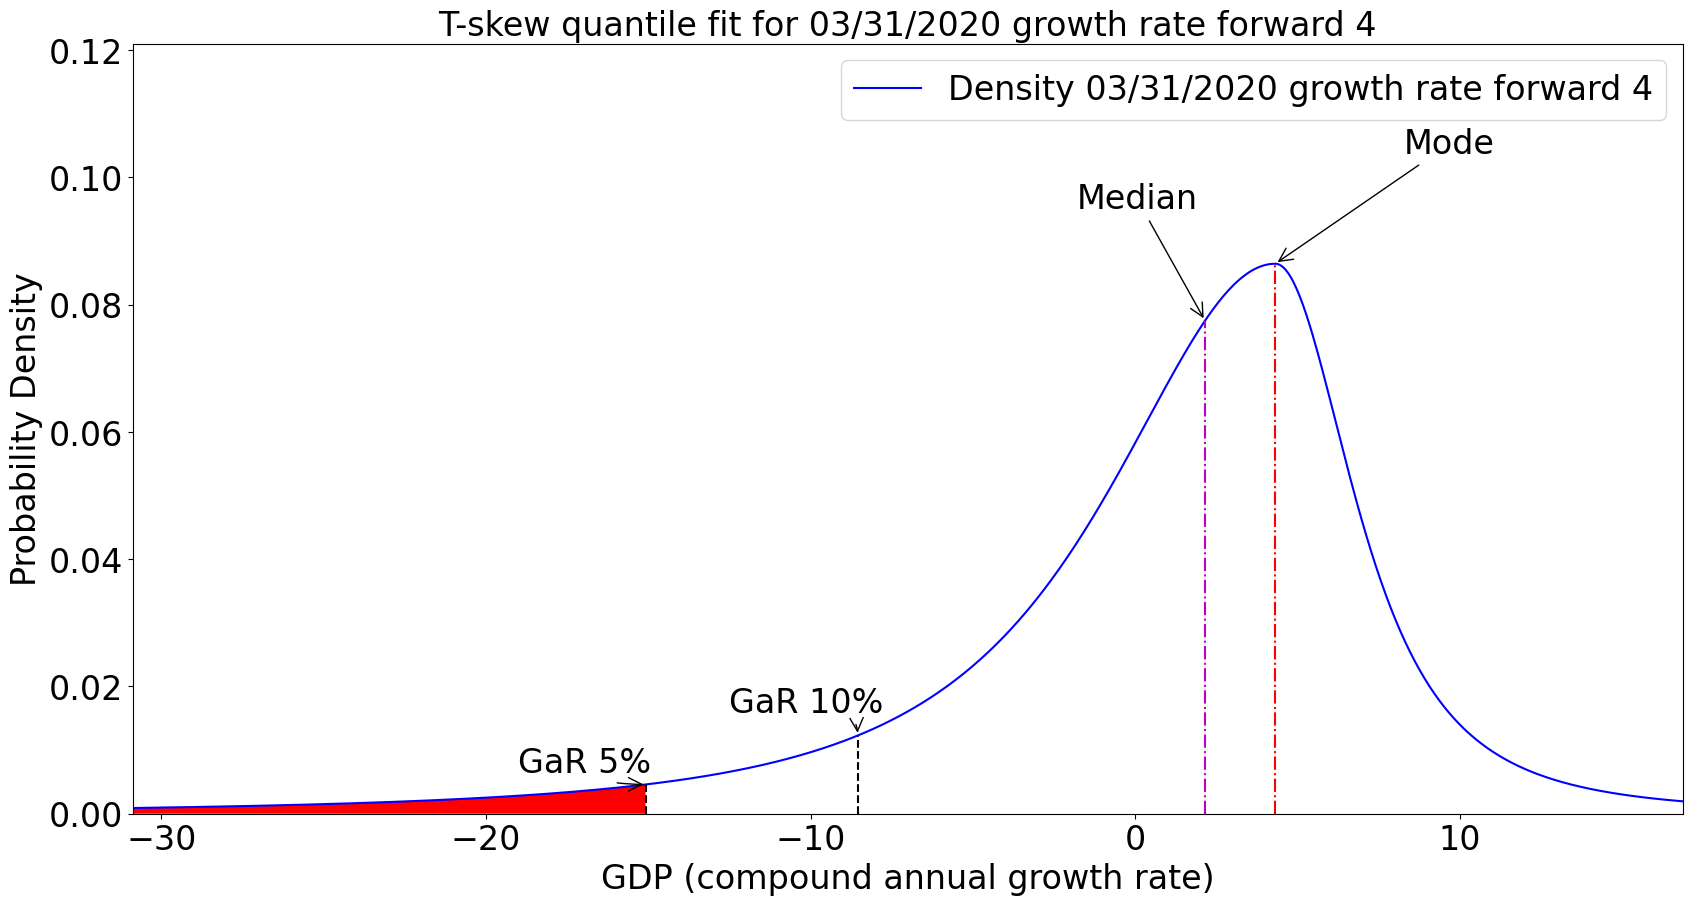

In [11]:
dict_output_tsfit['fig']

In [15]:
dict_output_tsfit['data'].to_dict('records')

[{'Tau': 0.1, 'Cond_quant': -6.7060385527380575},
 {'Tau': 0.15, 'Cond_quant': -5.254078069514655},
 {'Tau': 0.2, 'Cond_quant': -4.073629216428011},
 {'Tau': 0.25, 'Cond_quant': -4.310795230094506},
 {'Tau': 0.3, 'Cond_quant': -2.820216751732072},
 {'Tau': 0.35, 'Cond_quant': -2.2050140804067757},
 {'Tau': 0.4, 'Cond_quant': 1.0499930707283858},
 {'Tau': 0.45, 'Cond_quant': 1.852653051764465},
 {'Tau': 0.5, 'Cond_quant': 2.3751574905084447},
 {'Tau': 0.55, 'Cond_quant': 2.8134544024017405},
 {'Tau': 0.6, 'Cond_quant': 3.8953306568505375},
 {'Tau': 0.65, 'Cond_quant': 4.620589494891431},
 {'Tau': 0.7, 'Cond_quant': 5.5613498898656415},
 {'Tau': 0.75, 'Cond_quant': 6.157163451963485},
 {'Tau': 0.8, 'Cond_quant': 6.508069099864204},
 {'Tau': 0.85, 'Cond_quant': 6.657058477490889},
 {'Tau': 0.9, 'Cond_quant': 6.558280058859388}]

# Counterfactual Scenarios Analysis

In [24]:
df_partition.tail()

,date,real_y_ms,real_y_ms_yoy,consumer_AMD,consumer_USD,mortgage_AMD,mortgage_USD,business_AMD,business_USD,tbill,...,household_credit_stock_yoy,business_credit_stock_yoy,npl,loan_to_deposit,assets_equity,exchange_rate,net_tr_yoy,rus_y_yoy,copper_yoy,copper_yoy_lag2
72,2021-03-31,5.319483e+06,-0.079758,0.134378,0.113540,0.103914,0.096615,0.107566,0.078218,0.067319,...,0.076302,0.085681,0.071057,1.161439,7.519485,0.052927,0.703894,-0.030575,0.504671,0.124436
73,2021-06-30,5.420385e+06,-0.037814,0.135263,0.110210,0.106949,0.096300,0.103465,0.077698,0.070593,...,0.049485,0.009393,0.061312,1.085628,7.687599,0.079298,0.840539,0.010397,0.813952,0.218186
74,2021-09-30,5.455367e+06,-0.007347,0.137945,0.109063,0.107390,0.100013,0.109142,0.079134,0.081341,...,0.006112,-0.069649,0.050742,1.051230,7.820957,0.009644,0.482255,0.029425,0.437742,0.504671
75,2021-12-31,5.641248e+06,0.056842,0.137150,0.107825,0.108048,0.095063,0.108468,0.077583,0.086817,...,0.013430,-0.117363,0.035646,1.022209,7.718465,-0.079374,0.254740,0.047496,0.350469,0.813952
76,2022-03-31,5.732498e+06,0.077642,0.142228,0.108872,0.110017,0.091809,0.109980,0.077335,0.092928,...,0.043485,-0.049494,0.039666,1.065205,6.744862,-0.080144,0.046199,0.056547,0.177932,0.437742


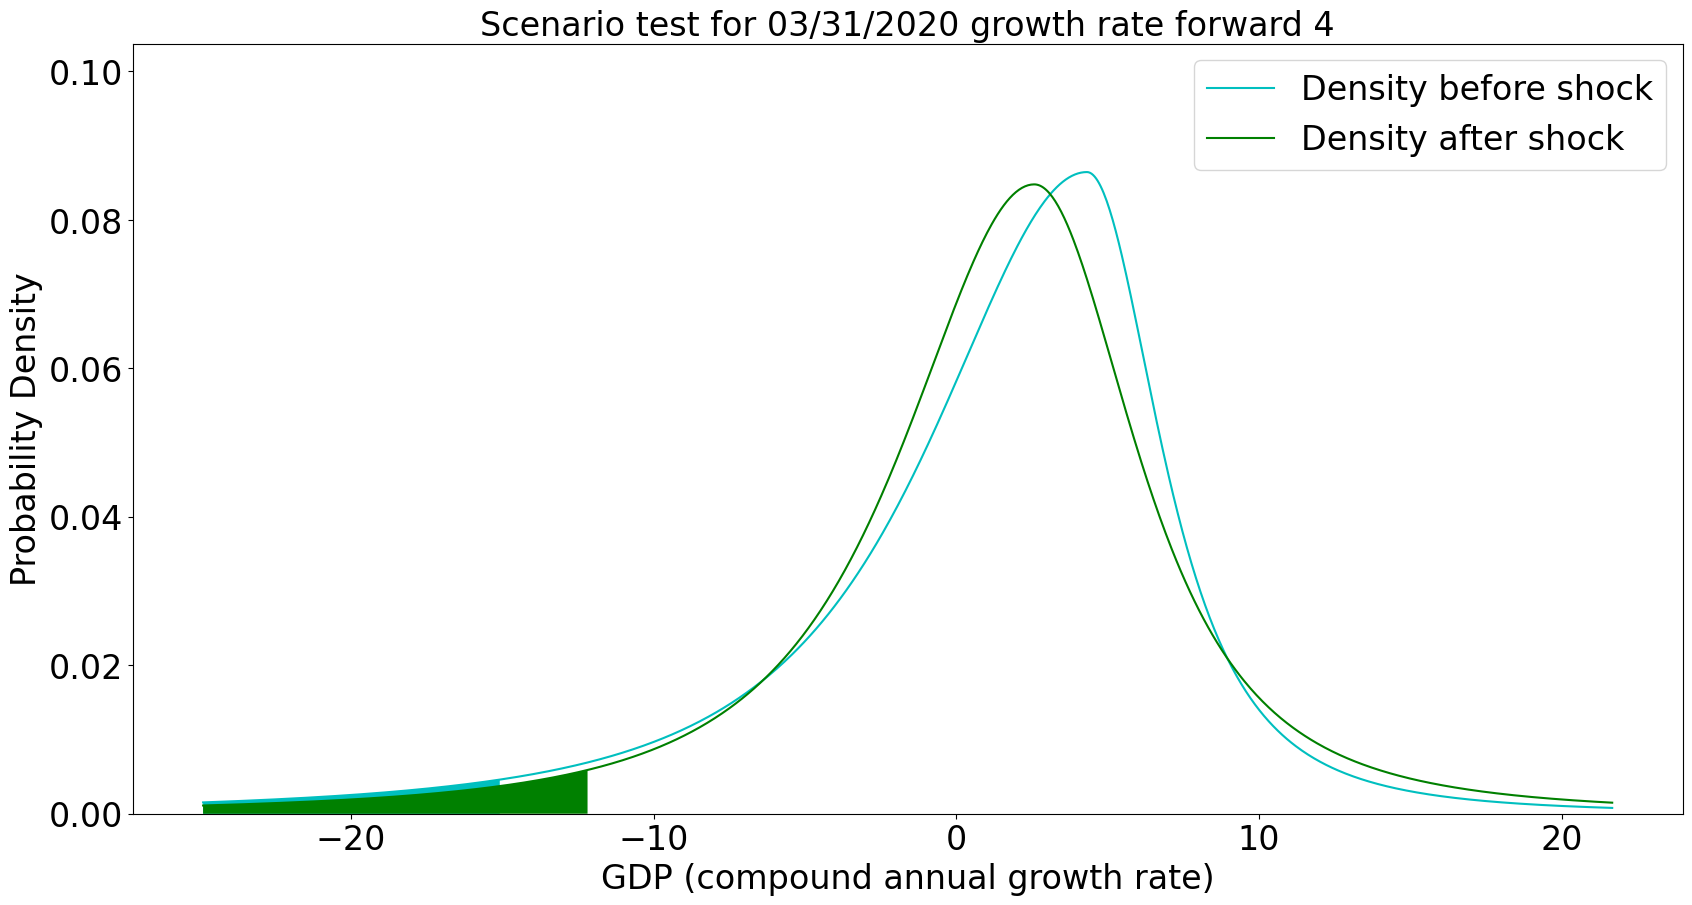

In [26]:
# scenario input data
latest_date = parser.parse('2020-03-31')
fit_params = {
    'fittype': 'T-skew',
    'mode': {'constraint': 'Free', 'value':None},
    'dof': {'constraint': 'Default', 'value': None},
    'var_low': {'constraint': 'Default', 'value': None},
    'var_high': {'constraint': 'Default', 'value': None},
    'skew_low': {'constraint': 'Default', 'value': None},
    'skew_high': {'constraint': 'Default', 'value': None}
}

fit_params_shocked = {
    'fittype': 'T-skew',
    'mode': {'constraint': 'Fix', 'value':4},
    'dof': {'constraint': 'Default', 'value': None},
    'var_low': {'constraint': 'Default', 'value': None},
    'var_high': {'constraint': 'Default', 'value': None},
    'skew_low': {'constraint': 'Default', 'value': None},
    'skew_high': {'constraint': 'Default', 'value': None}
}
# shocktype: 'By +/- STD' or 'By +/- percentage' 
shockvars = {
    'tbill': {
        'shocktype': 'By +/- STD',
        'shockvalue': 10
    }
}
# generating shocked series
transformer = DataTransformer()
df_shockedvar, df_shockedgrp = gen_shocked_PCA(shockvars, dict_groups, df_partition, 
                                               transformer, **dict_global_params)
df_shockedgrp.columns = df_shockedgrp.columns.str.replace('_shocked', '')

# calculating conditional quantiles
cond_quant = get_cond_quant(latest_date, macro_data, qcoef, **dict_global_params)
cond_quant_shocked = get_cond_quant(latest_date, df_shockedgrp, qcoef, **dict_global_params)

dict_output_scenario = run_scenario(latest_date, cond_quant, cond_quant_shocked, 
                                    fit_params, fit_params_shocked, **dict_global_params)
dict_output_scenario['fig'].savefig('../Results/Scenario_test.png', bbox_inches='tight', dpi=300)
dict_output_scenario['fig']

In [27]:
print('Results')
print(pd.DataFrame(dict_output_scenario['res']))

Results
                  0                    1                    2
0                           Before shock          After shock
1     Date of input  2020-03-31 00:00:00  2020-03-31 00:00:00
2   Horizon forward                    4                    4
3  Conditional mode               4.3176               2.5776
4             GaR5%           -15.079402           -12.179402
5            GaR10%            -8.579402            -7.079402
6          Skewness               0.6854               0.8786
7             Scale               3.8144               4.1352


# Historical dist

In [16]:
# mode: Free vs Fixed
# fittype: 'T-skew' vs "Asymmetric T"
# qsmooth: 'None' vs 'Median' vs 'Mean'
hist_fit_params = {
    'fittype': 'T-skew',
    'mode': {'constraint': 'Free', 'value':None},
    'qsmooth': 'Mean',
    'qsmooth_period': 4,
    'dof': {'constraint': 'Default', 'value': None},
    'var_low': {'constraint': 'Default', 'value': None},
    'var_high': {'constraint': 'Default', 'value': None},
    'skew_low': {'constraint': 'Default', 'value': None},
    'skew_high': {'constraint': 'Default', 'value': None}
}

dict_input_historical = {
    'start_date': parser.parse('2003-03-31'),
    'end_date': parser.parse('2022-03-31'),
    'time_inc': 1,
    'fit_params': hist_fit_params,
    **dict_global_params
}
dict_output_historical = run_historical(dict_input_historical, macro_data, qcoef)

In [17]:
hist_sim_data = dict_output_historical['data']
hist_sim_data.head()

,location,scale,skew,dfpdf,var10%,var15%,var20%,var25%,var30%,var35%,...,var50%,var55%,var60%,var65%,var70%,var75%,var80%,var85%,var90%,var5%
2004-03-31,1.819502,4.5092,0.5520,Tskew_PDF_x Tskew_PDF_y Tskew_CDF 0 ...,-12.134876,-7.431841,-4.469873,-2.330657,-0.656041,0.727365,...,3.921127,4.803485,5.634212,6.428568,7.199030,7.956388,8.715370,9.552929,10.658022,-22.191937
2004-06-30,2.811085,3.3740,0.5520,Tskew_PDF_x Tskew_PDF_y Tskew_CDF 0 ...,-5.734298,-2.215261,0.001026,1.601690,2.854718,3.889848,...,6.279574,6.939797,7.561387,8.155762,8.732259,9.298951,9.866858,10.493559,11.320443,-13.259474
2004-09-30,4.337738,2.4291,0.5470,Tskew_PDF_x Tskew_PDF_y Tskew_CDF 0 ...,-0.548879,2.011789,3.624084,4.788208,5.699236,6.451599,...,8.187294,8.666400,9.117245,9.548112,9.965759,10.376017,10.786202,11.235870,11.826181,-6.025994
2004-12-31,11.073006,1.1273,0.5077,Tskew_PDF_x Tskew_PDF_y Tskew_CDF 0 ...,6.828538,8.124429,8.938802,9.525595,9.983797,10.361296,...,11.227609,11.465173,11.687898,11.899882,12.104427,12.304329,12.502098,12.707811,12.965095,4.051627
2005-03-31,14.466183,0.9374,0.5965,Tskew_PDF_x Tskew_PDF_y Tskew_CDF 0 ...,9.739555,10.631659,11.194853,11.602652,11.922771,12.188016,...,12.804471,12.976215,13.138684,13.294868,13.447261,13.598111,13.754290,13.935543,14.183763,7.836185


In [18]:
# dict_output_historical['figs']['res']

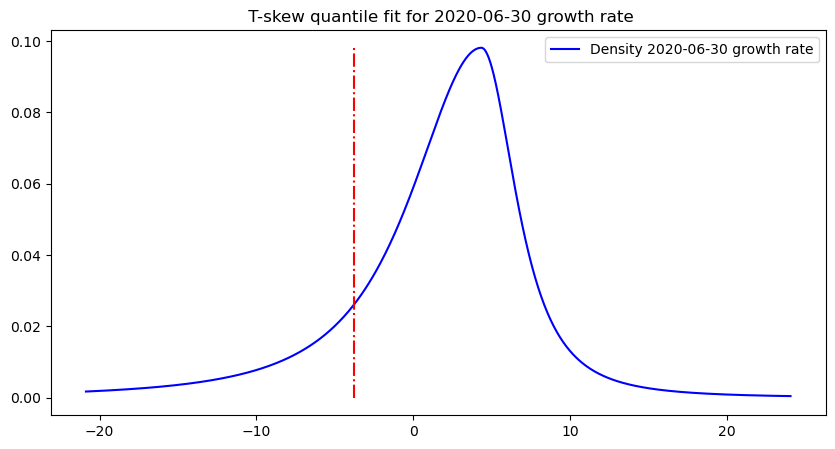

In [19]:
dict_output_historical['charts'][-1]

# Multiple Horizon Projections

In [20]:
# qsmooth_period: int or "auto" (in case of auto its equal to the horizon)
segment_fit_params = {
    'fittype': 'T-skew',
    'mode': {},
    'qsmooth': "None",
    'qsmooth_period': 2,
    'dof': {'constraint': 'Default', 'value': None},
    'var_low': {'constraint': 'Default', 'value': None},
    'var_high': {'constraint': 'Default', 'value': None},
    'skew_low': {'constraint': 'Default', 'value': None},
    'skew_high': {'constraint': 'Default', 'value': None}
}

dict_input_segment = {
    'horizonlist': [4, 8, 12, 16],
    'method_growth':'cpd',
    'retropolate':'Yes',
    'partition_groups': dict_groups,
    'transformer':transformer,
    'quantlist':[0.1, 0.25, 0.5, 0.75, 0.9],
    'fitdate': parser.parse('6/30/2018'),
    'fit_params': segment_fit_params,
    'fitconstrainlist': ['Free']*4,
    'fitconstrainvalues': [None]*4,
    **dict_global_params
}
dict_output_segment = run_segment(dict_input_segment, df_partition, model=sm.QuantReg)

/Users/victoryerz/opt/anaconda3/lib/python3.9/site-packages/statsmodels/regression/quantile_regression.py:191: IterationLimitWarning:

Maximum number of iterations (1000) reached.

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


In [21]:
pd.DataFrame(dict_output_segment['res'])

,horizon,df_quantcoef,olsmean,cond_quant,tsfit,dfpdf,loc
0,4,variable ho...,3.083864,"{0.1: -0.6241787710521818, 0.25: -0.4671697766...","{'loc': 4.6441, 'df': 2, 'scale': 2.7229, 'ske...",Tskew_PDF_x Tskew_PDF_y Tskew_CDF 0 ...,4.6441
1,8,variable ho...,1.373040,"{0.1: -1.3090591916780376, 0.25: -0.3580015091...","{'loc': 1.0285, 'df': 2, 'scale': 2.2553, 'ske...",Tskew_PDF_x Tskew_PDF_y Tskew_CDF 0 ...,1.0285
2,12,variable ho...,0.423643,"{0.1: -0.5718478891472096, 0.25: -0.6174252492...","{'loc': -0.5875, 'df': 2, 'scale': 1.1128, 'sk...",Tskew_PDF_x Tskew_PDF_y Tskew_CDF 0 ...,-0.5875
3,16,variable ho...,0.052014,"{0.1: -2.364620862448931, 0.25: 0.914522670695...","{'loc': 1.8644, 'df': 2, 'scale': 0.8135, 'ske...",Tskew_PDF_x Tskew_PDF_y Tskew_CDF 0 ...,1.8644


In [22]:
dict_output_segment['tails']

[['Forward horizon', 4, 8, 12, 16],
 ['Conditional mode', 4.6441, 1.0285, -0.5875, 1.8644],
 ['Conditional median', 4.1972, 1.8811, 0.7886, 1.1757],
 ['Conditional mean', 3.755, 2.6985, 1.9517, 0.564],
 ['GaR5%', -4.857, -3.2369, -1.3941, -3.2462],
 ['GaR10%', -1.5595, -1.618, -0.98, -1.5495],
 ['Growth below 0 probablity', 0.1493, 0.2294, 0.3291, 0.2334]]

In [23]:
dict_output_segment['dfpdf'].head()

,Tskew_PDF_x,Tskew_PDF_y_PROJ1,Tskew_CDF_y_PROJ1,Tskew_PDF_y_PROJ2,Tskew_CDF_y_PROJ2,Tskew_PDF_y_PROJ3,Tskew_CDF_y_PROJ3,Tskew_PDF_y_PROJ4,Tskew_CDF_y_PROJ4
0,-13.086668,0.001712,0.015847,0.000769,0.005553,0.000054,0.000336,0.000846,0.006403
1,-13.036668,0.001726,0.015933,0.000777,0.005592,0.000054,0.000339,0.000854,0.006446
2,-12.986668,0.001740,0.016019,0.000785,0.005631,0.000055,0.000342,0.000862,0.006489
3,-12.936668,0.001754,0.016107,0.000794,0.005670,0.000056,0.000344,0.000871,0.006532
4,-12.886668,0.001768,0.016195,0.000802,0.005710,0.000056,0.000347,0.000880,0.006576


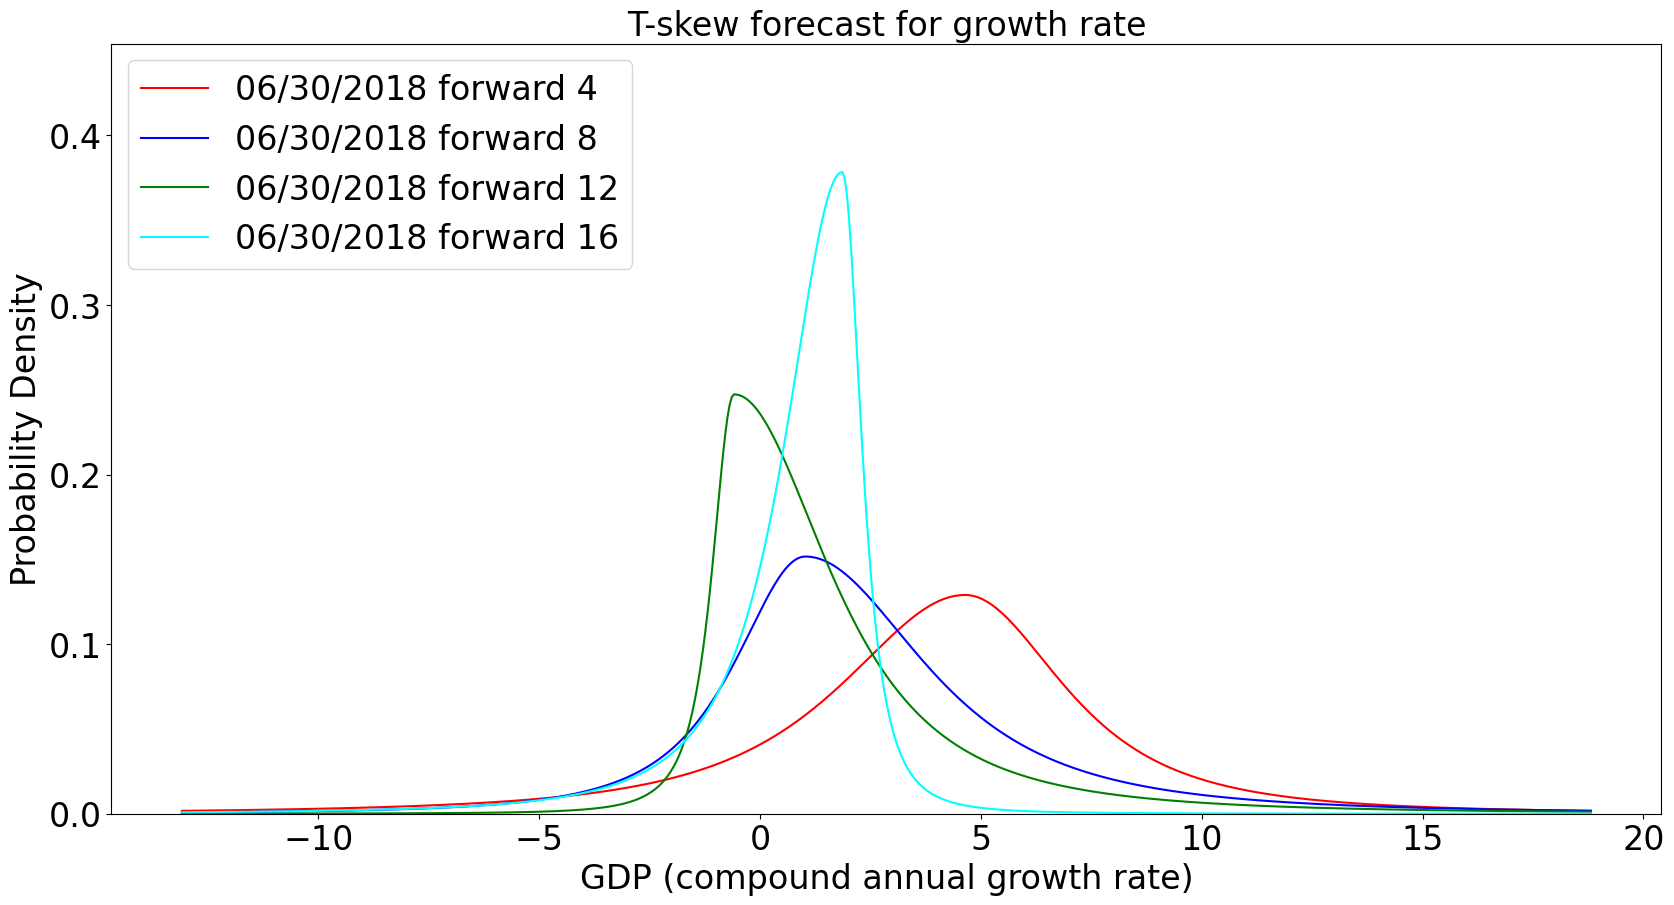

In [24]:
dict_output_segment['fig']

In [25]:
# df_term['error_hz'+str(horizon)]=(df_quantcoef['upper']-df_quantcoef['lower'])/2
# loc=tsfit['loc']/tsfit['scale']
# loc=tsfit['loc']

# Results

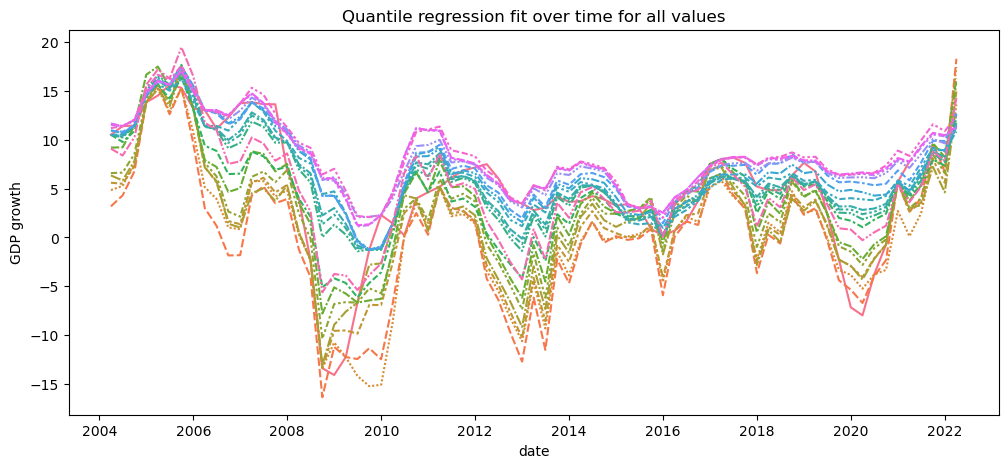

In [26]:
sns.reset_defaults()
qfit_series = cond_quant_series.pivot_table(values='conditional_quantile_mean', index='date', columns='tau')
qfit_series = pd.merge(qfit_series, macro_data[['date','real_y_ms_hz_4']], how='left', on='date')
qfit_series = qfit_series[[qfit_series.columns[-1]] + list(qfit_series.columns[:-1])]
qfit_series = qfit_series.set_index('date')
# palette = {
#     0.1: 'red',
#     0.25: 'green',
#     0.5: 'orange',
#     0.75: 'purple',
#     0.9: 'brown',
#     'mean': 'gray',
#     'real_y_ms_hz_4': 'black'
# }
fig, ax = plt.subplots(figsize=(12, 5))
# sns.lineplot(data=qfit_series, palette=palette, ax=ax)
g = sns.lineplot(data=qfit_series, ax=ax)
plt.title('Quantile regression fit over time for all values')
plt.ylabel('GDP growth')
# plt.savefig('../Results/QRfit_over_time.png', bbox_inches='tight', dpi=300)
plt.legend([], [], frameon=False)
plt.show()

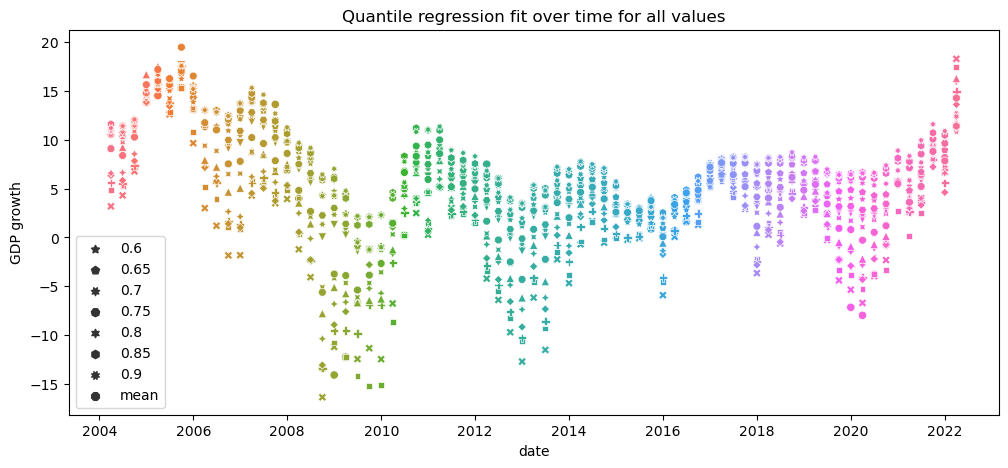

In [27]:
qdist = qfit_series.reset_index().melt(id_vars='date', value_vars=['real_y_ms_hz_4',*quantlist, 'mean'])
fig, ax = plt.subplots(figsize=(12, 5))

sns.scatterplot(data=qdist, x='date', y='value', hue='date', style='variable', legend=True, ax=ax)
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[-8:], labels[-8:], frameon=True)
plt.title('Quantile regression fit over time for all values')
plt.ylabel('GDP growth') 
# plt.savefig('../Results/QRfit_points_over_time.png', bbox_inches='tight', dpi=300)
plt.show()

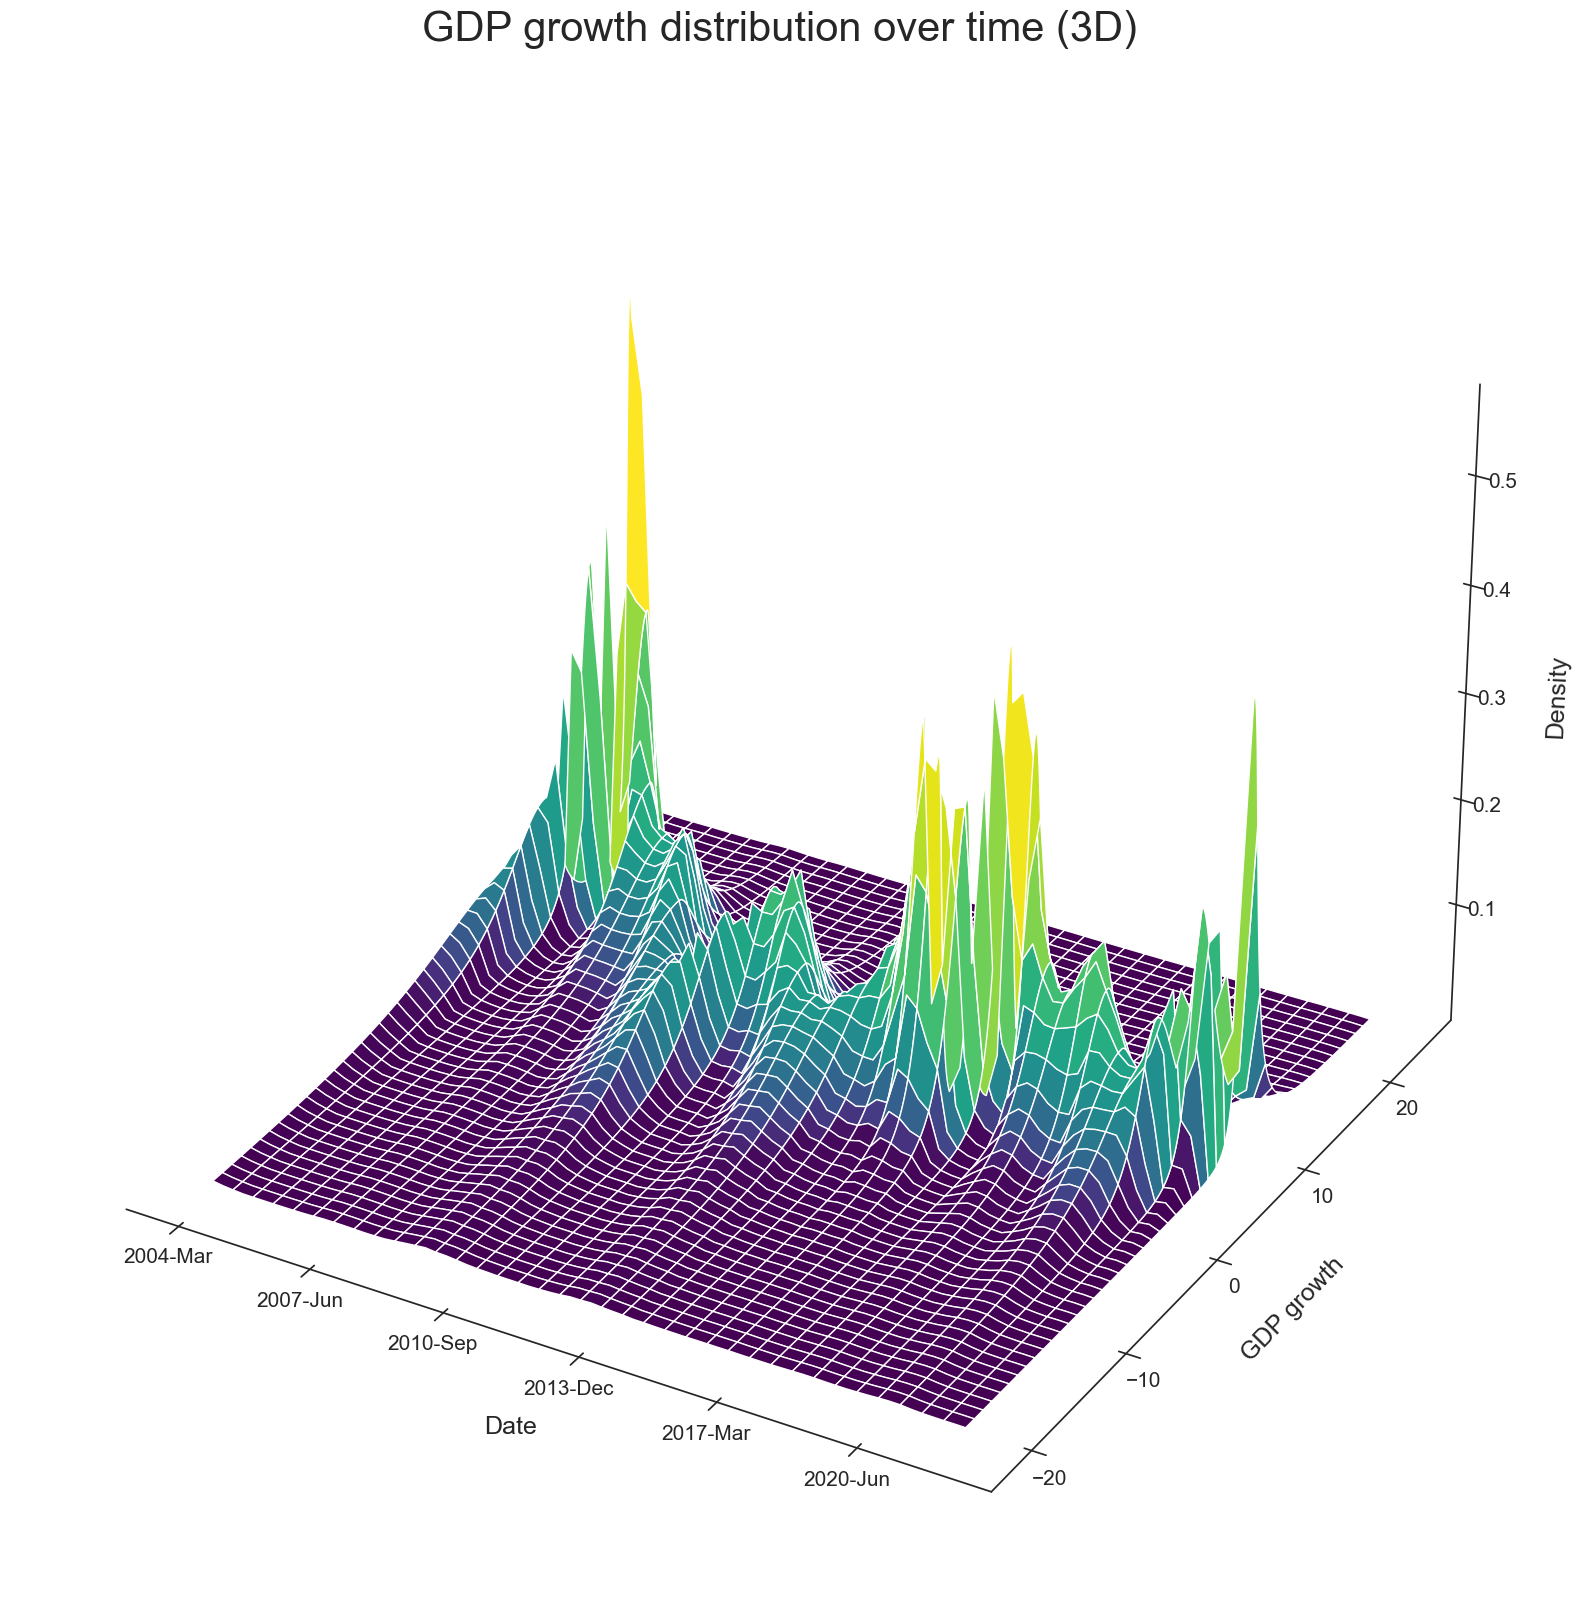

In [28]:
# custom outline
sns.set_theme(style="white", palette='viridis')

# Data preparation
# Tskew vs AsymT
method = 'Tskew'
df_PDF = pd.concat(hist_sim_data['dfpdf'].values, keys=hist_sim_data['dfpdf'].index).reset_index(level=1, drop=True)
df_PDF = df_PDF.reset_index().rename(columns={'index':'date'})
gdp_growth = df_PDF.groupby('date')[method+'_PDF_x'].apply(lambda x: list(x)).apply(lambda x: pd.Series(x))
gdp_density = df_PDF.groupby('date')[method+'_PDF_y'].apply(lambda x: list(x)).apply(lambda x: pd.Series(x))
dates = gdp_growth.index
dates_grid = np.repeat(dates, len(gdp_growth.columns)).to_numpy().reshape(-1, len(gdp_growth.columns))
dates_grid_values = np.repeat(np.arange(len(dates)), len(gdp_growth.columns)).reshape(-1, len(gdp_growth.columns))

# 3D plotting
fig = plt.figure(figsize=(20, 20))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(dates_grid_values, gdp_growth, gdp_density, cmap=cm.viridis, 
                norm=matcolors.SymLogNorm(linthresh=0.02, linscale=0.03))
ax.set_xticks(np.arange(len(dates))[0::13])
ax.set_xticklabels(dates[0::13].strftime('%Y-%b'))
ax.set_xlabel('Date', fontsize=18, labelpad=20)
ax.set_ylabel('GDP growth', fontsize=18, labelpad=20)
ax.set_zlabel('Density', fontsize=18, labelpad=20)
ax.tick_params(axis='both', which='major', labelsize=15)
ax.set_title('GDP growth distribution over time (3D)', fontsize=30)

# make the panes transparent
ax.xaxis.set_pane_color((1.0, 1.0, 1.0, 0.0))
ax.yaxis.set_pane_color((1.0, 1.0, 1.0, 0.0))
ax.zaxis.set_pane_color((1.0, 1.0, 1.0, 0.0))

# make the grid lines transparent
ax.xaxis._axinfo["grid"]['color'] =  (1,1,1,0)
ax.yaxis._axinfo["grid"]['color'] =  (1,1,1,0)
ax.zaxis._axinfo["grid"]['color'] =  (1,1,1,0)
# plt.savefig('../Results/GDP_growth_dist_3D.png', bbox_inches='tight', dpi=300)
plt.show()

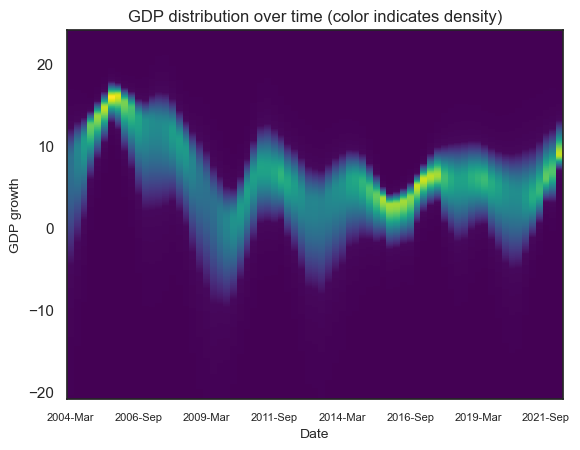

In [29]:
sns.reset_defaults()
sns.set_theme(style="white", rc={"axes.facecolor": (0, 0, 0, 0)})

fig, ax = plt.subplots(1, 1)
ax.pcolormesh(dates_grid_values, gdp_growth, gdp_density, cmap=cm.viridis,
              norm=matcolors.SymLogNorm(linthresh=0.02, linscale=0.03))
ax.set_xticks(np.arange(len(dates))[0::10])
ax.set_xticklabels(dates[0::10].strftime('%Y-%b'), fontsize=8)
ax.set_xlabel('Date', fontsize=10)
ax.set_ylabel('GDP growth', fontsize=10)
plt.title('GDP distribution over time (color indicates density)')
# plt.savefig('../Results/GDP_growth_dist_2D.png', bbox_inches='tight', dpi=300)
plt.show()

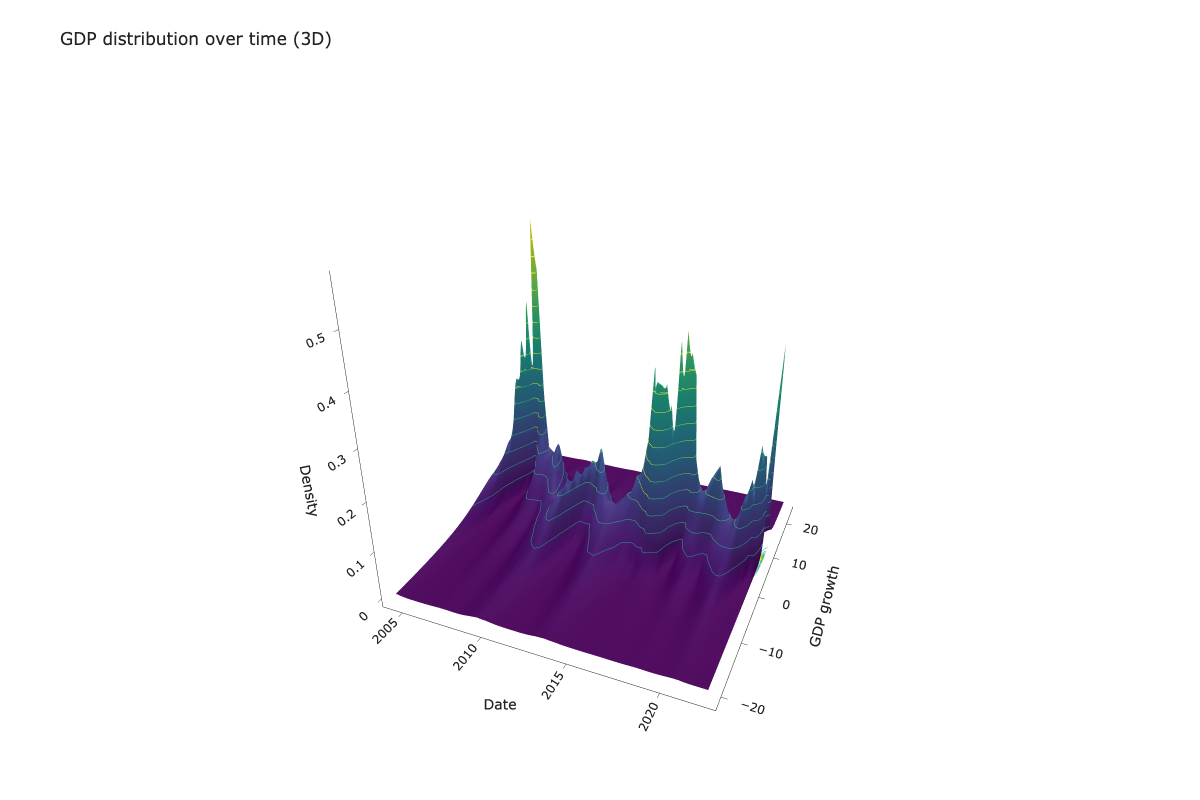

In [30]:
# scaler = prep.Normalizer('l1')
# surf_color = scaler.fit_transform(gdp_density.values.reshape((1, -1))).reshape(gdp_density.values.shape)
surf_color = gdp_density

contours = {
    "z": {"show": True, "start": 0, "end": 1, 
          "size": 1/30, "width": 16, "color": 'white',
          'usecolormap':True, 'highlightcolor':"limegreen",
          'project_z':True
         }
}
surf = go.Surface(x=dates_grid, y=gdp_growth, z=gdp_density,
                  surfacecolor=surf_color, colorscale='Viridis',
                  connectgaps=True, opacity=1, showscale=False,
                  contours=contours)
fig = go.Figure(data=[surf])

fig.update_layout(
    template='simple_white',
    title='GDP distribution over time (3D)',
    autosize=False,
    scene=dict(
        camera_eye=dict(x=0.8, y=-1.9, z=1),
        xaxis_title='Date',
        yaxis_title='GDP growth',
        zaxis_title='Density'
    ),
    width=1200,
    height=800,
    margin=dict(l=65, r=50, b=65, t=90),
)
# fig.write_html('../Results/GDP_dist_interactive.html')
fig.show(renderer='png', width=1200, height=800)

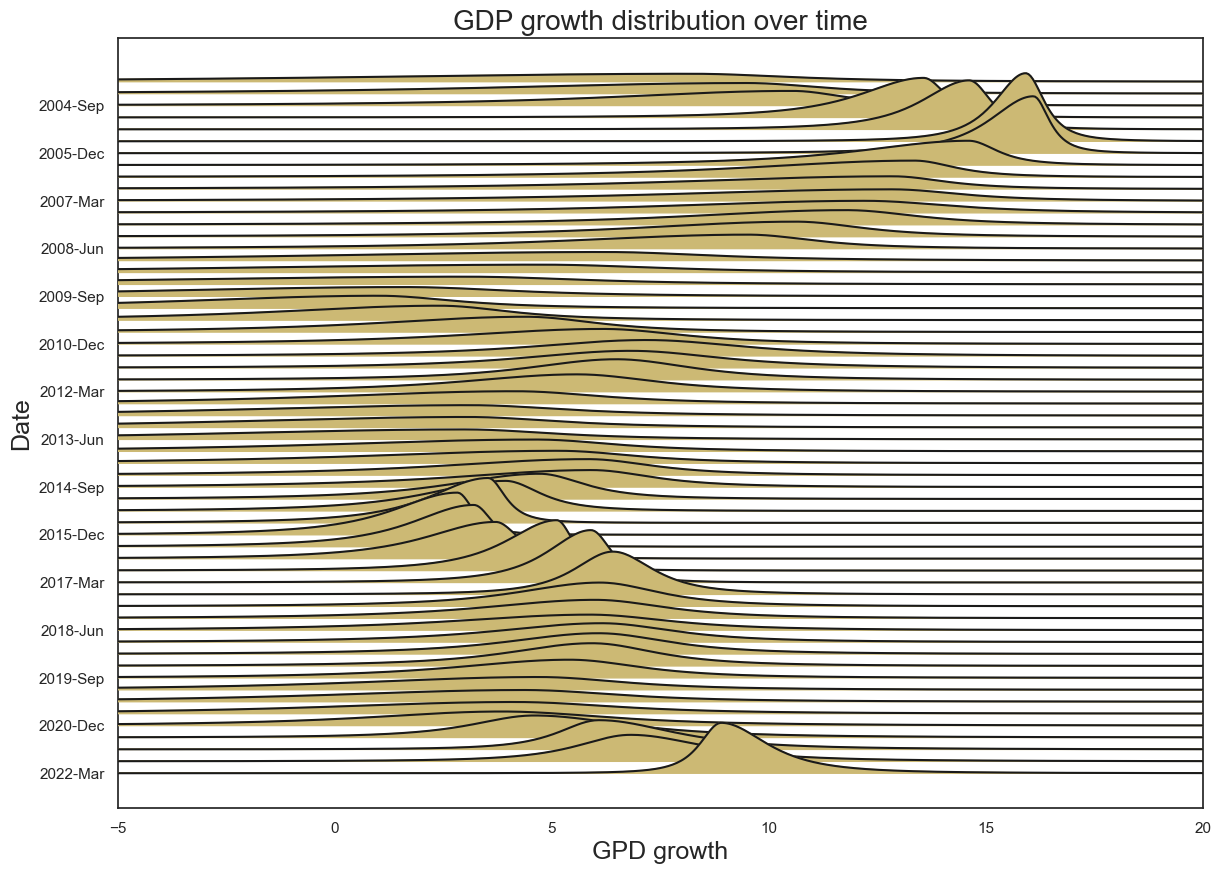

In [31]:
plt.figure(figsize=(14,10))        
plot_data = df_PDF.set_index('date').copy()
ridgeline_custom(plot_data['Tskew_PDF_x'], plot_data['Tskew_PDF_y'], overlap=0.9, fill=True,
                 outline=True, inline=False, y_fontsize=14, y_interval=4, 
                 dist_density=5, line_color='k', fill_color='y')
plt.title('GDP growth distribution over time', fontsize=20)
plt.xlabel('GPD growth',  fontsize=18)
plt.ylabel('Date',  fontsize=18)
plt.xlim(-5, 20)
# plt.savefig('../Results/GDP_growth_ridge.png', bbox_inches='tight', dpi=300)
plt.show()